# Demo 2 — Trigger inference.py via Datastream Re-Insert

**Run inference.py in a separate terminal first:**
```
python inference.py --mode listen --install-db-objects
```

This notebook then:
1. Finds the latest row for Site 1 AirTemp, Site 3 Discharge, Site 4 Discharge.
2. Deletes all rows at that exact timestamp (clears duplicates from prior runs).
3. Re-inserts the same row — the PostgreSQL trigger fires and inference.py picks it up.
4. Polls `model_predictions` until all 3 × 24 = 72 prediction rows appear.
5. Displays the predictions.
6. Cleans up the test rows and their predictions.

## 1. Setup

In [2]:
from __future__ import annotations

import os
import sys
import time
from datetime import timedelta
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import pandas as pd

# ── Locate project root ───────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "inference.py").exists():
    candidate = PROJECT_ROOT / "CS6994FinalProject"
    if candidate.exists():
        PROJECT_ROOT = candidate

sys.path.insert(0, str(PROJECT_ROOT))
import inference

# ── DB connection ─────────────────────────────────────────────────────────────
db_args = SimpleNamespace(
    db_host=os.environ.get("DB_HOST", "localhost"),
    db_port=int(os.environ.get("DB_PORT", "5433")),
    db_name=os.environ.get("DB_NAME", "database"),
    db_user=os.environ.get("DB_USER", "admin"),
    db_password=os.environ.get("DB_PASSWORD", "password"),
)

TARGET_SITES = [
    {"site_id": 1, "variable_code": "AirTemp"},
    {"site_id": 3, "variable_code": "Discharge"},
    {"site_id": 4, "variable_code": "Discharge"},
]

conn = inference.connect_db(db_args)
print(f"Connected: {db_args.db_user}@{db_args.db_host}:{db_args.db_port}/{db_args.db_name}")

Connected: admin@localhost:5433/database


## 2. Delete duplicates at the latest timestamp and re-insert

Re-inserting fires the PostgreSQL `AFTER INSERT` trigger which sends
`pg_notify('datastream_hourly_insert', ...)` — inference.py in your
terminal receives that and writes predictions to `model_predictions`.

In [3]:
def fetch_latest_row(conn, site_id: int, variable_code: str) -> dict:
    sql = """
        SELECT d.*
        FROM   datastream d
        JOIN   variable   v ON d.variable_id = v.variable_id
        WHERE  d.site_id       = %s
          AND  v.variable_code = %s
        ORDER  BY d.datetime_utc DESC, d.datastream_id DESC
        LIMIT  1
    """
    with conn.cursor(cursor_factory=inference.DictCursor) as cur:
        cur.execute(sql, (site_id, variable_code))
        row = cur.fetchone()
    if row is None:
        raise ValueError(f"No data for site_id={site_id} variable_code={variable_code}")
    return dict(row)


def delete_all_at_timestamp(conn, site_id: int, variable_id: int, datetime_utc) -> int:
    """Delete ALL rows at this (site, variable, timestamp) to clear duplicates.

    fetch_latest_existing_timestamp in inference.py queries
    MAX(datetime_utc) WHERE datastream_id <> new_id.
    If any other row exists at the same timestamp that query returns
    the same time, the 'not newer' guard skips inference.
    Deleting everything at that timestamp before re-inserting guarantees
    the new row is the sole occupant and the guard passes.
    """
    with conn.cursor() as cur:
        cur.execute(
            "DELETE FROM datastream "
            "WHERE site_id = %s AND variable_id = %s AND datetime_utc = %s",
            (site_id, variable_id, datetime_utc),
        )
        count = cur.rowcount
    conn.commit()
    return count


def reinsert_row(conn, original: dict) -> int:
    sql = """
        INSERT INTO datastream
            (site_id, variable_id, datetime_utc, value,
             owner_id, qualifier_id, processing_level_id)
        VALUES (%s, %s, %s, %s, %s, %s, %s)
        RETURNING datastream_id
    """
    with conn.cursor() as cur:
        cur.execute(sql, (
            original["site_id"],
            original["variable_id"],
            original["datetime_utc"],
            original["value"],
            original.get("owner_id"),
            original.get("qualifier_id"),
            original.get("processing_level_id"),
        ))
        new_id = cur.fetchone()[0]
    conn.commit()
    return int(new_id)


# ── Delete + re-insert ────────────────────────────────────────────────────────
inserted_records = []

for target in TARGET_SITES:
    site_id       = target["site_id"]
    variable_code = target["variable_code"]

    original = fetch_latest_row(conn, site_id, variable_code)
    var_id   = int(original["variable_id"])
    ts       = original["datetime_utc"]
    val      = original["value"]

    print(f"site={site_id} {variable_code}: latest  {ts}  value={val}")

    deleted = delete_all_at_timestamp(conn, site_id, var_id, ts)
    print(f"  deleted {deleted} row(s) at {ts}")

    new_id = reinsert_row(conn, original)
    print(f"  re-inserted → datastream_id={new_id}  (trigger fired)\n")

    inserted_records.append({
        **target,
        "new_datastream_id": new_id,
        "datetime_utc": ts,
        "value": val,
    })

inserted_ids = [r["new_datastream_id"] for r in inserted_records]
print("Waiting for inference.py to write predictions...")
pd.DataFrame(inserted_records)[["site_id", "variable_code", "datetime_utc", "value", "new_datastream_id"]]

site=1 AirTemp: latest  2026-03-24 19:00:00  value=15.76
  deleted 1 row(s) at 2026-03-24 19:00:00
  re-inserted → datastream_id=4067886  (trigger fired)

site=3 Discharge: latest  2026-03-24 08:00:00  value=214.2
  deleted 1 row(s) at 2026-03-24 08:00:00
  re-inserted → datastream_id=4067887  (trigger fired)

site=4 Discharge: latest  2026-03-24 21:00:00  value=354.3
  deleted 1 row(s) at 2026-03-24 21:00:00
  re-inserted → datastream_id=4067888  (trigger fired)

Waiting for inference.py to write predictions...


,site_id,variable_code,datetime_utc,value,new_datastream_id
0,1,AirTemp,2026-03-24 19:00:00,15.76,4067886
1,3,Discharge,2026-03-24 08:00:00,214.20,4067887
2,4,Discharge,2026-03-24 21:00:00,354.30,4067888


## 3. Poll `model_predictions` until inference.py has written all results

In [4]:
POLL_INTERVAL  = 3    # seconds between checks
POLL_TIMEOUT   = 120  # give up after 2 minutes
EXPECTED_ROWS  = len(inserted_ids) * 24  # 24 steps per event

print(f"Polling every {POLL_INTERVAL}s (timeout {POLL_TIMEOUT}s) for {EXPECTED_ROWS} prediction rows...")

start = time.time()
pred_df = pd.DataFrame()

while time.time() - start < POLL_TIMEOUT:
    with conn.cursor(cursor_factory=inference.DictCursor) as cur:
        cur.execute(
            "SELECT * FROM model_predictions WHERE source_datastream_id = ANY(%s) ORDER BY target_variable, site_id, horizon",
            (inserted_ids,),
        )
        rows = cur.fetchall()

    n = len(rows)
    elapsed = time.time() - start
    print(f"  [{elapsed:5.1f}s]  {n}/{EXPECTED_ROWS} rows found", end="")

    if n >= EXPECTED_ROWS:
        pred_df = pd.DataFrame([dict(r) for r in rows])
        print("  ✓ done")
        break

    found_ids = {r["source_datastream_id"] for r in rows}
    missing   = [i for i in inserted_ids if i not in found_ids]
    print(f"  (waiting for datastream_ids: {missing})")
    time.sleep(POLL_INTERVAL)
else:
    print(f"\nTimeout after {POLL_TIMEOUT}s — check that inference.py is running in --mode listen.")

print(f"\nTotal prediction rows received: {len(pred_df)}")

Polling every 3s (timeout 120s) for 72 prediction rows...
  [  0.0s]  72/72 rows found  ✓ done

Total prediction rows received: 72


## 4. Display predictions

In [5]:
if pred_df.empty:
    print("No predictions — check inference.py terminal output.")
else:
    print(pred_df[["target_variable", "site_id", "season", "horizon", "target_timestamp", "prediction"]].to_string(index=False))

target_variable  site_id season  horizon    target_timestamp  prediction
air_temperature        1 spring        1 2026-03-24 20:00:00   16.265766
air_temperature        1 spring        2 2026-03-24 21:00:00   16.443100
air_temperature        1 spring        3 2026-03-24 22:00:00   16.225454
air_temperature        1 spring        4 2026-03-24 23:00:00   15.334632
air_temperature        1 spring        5 2026-03-25 00:00:00   14.620476
air_temperature        1 spring        6 2026-03-25 01:00:00   12.889255
air_temperature        1 spring        7 2026-03-25 02:00:00   10.800511
air_temperature        1 spring        8 2026-03-25 03:00:00    8.764201
air_temperature        1 spring        9 2026-03-25 04:00:00    7.382508
air_temperature        1 spring       10 2026-03-25 05:00:00    6.148211
air_temperature        1 spring       11 2026-03-25 06:00:00    5.885312
air_temperature        1 spring       12 2026-03-25 07:00:00    5.326365
air_temperature        1 spring       13 2026-03-25

## 5. Plot: 72-hour history + 24-hour forecast

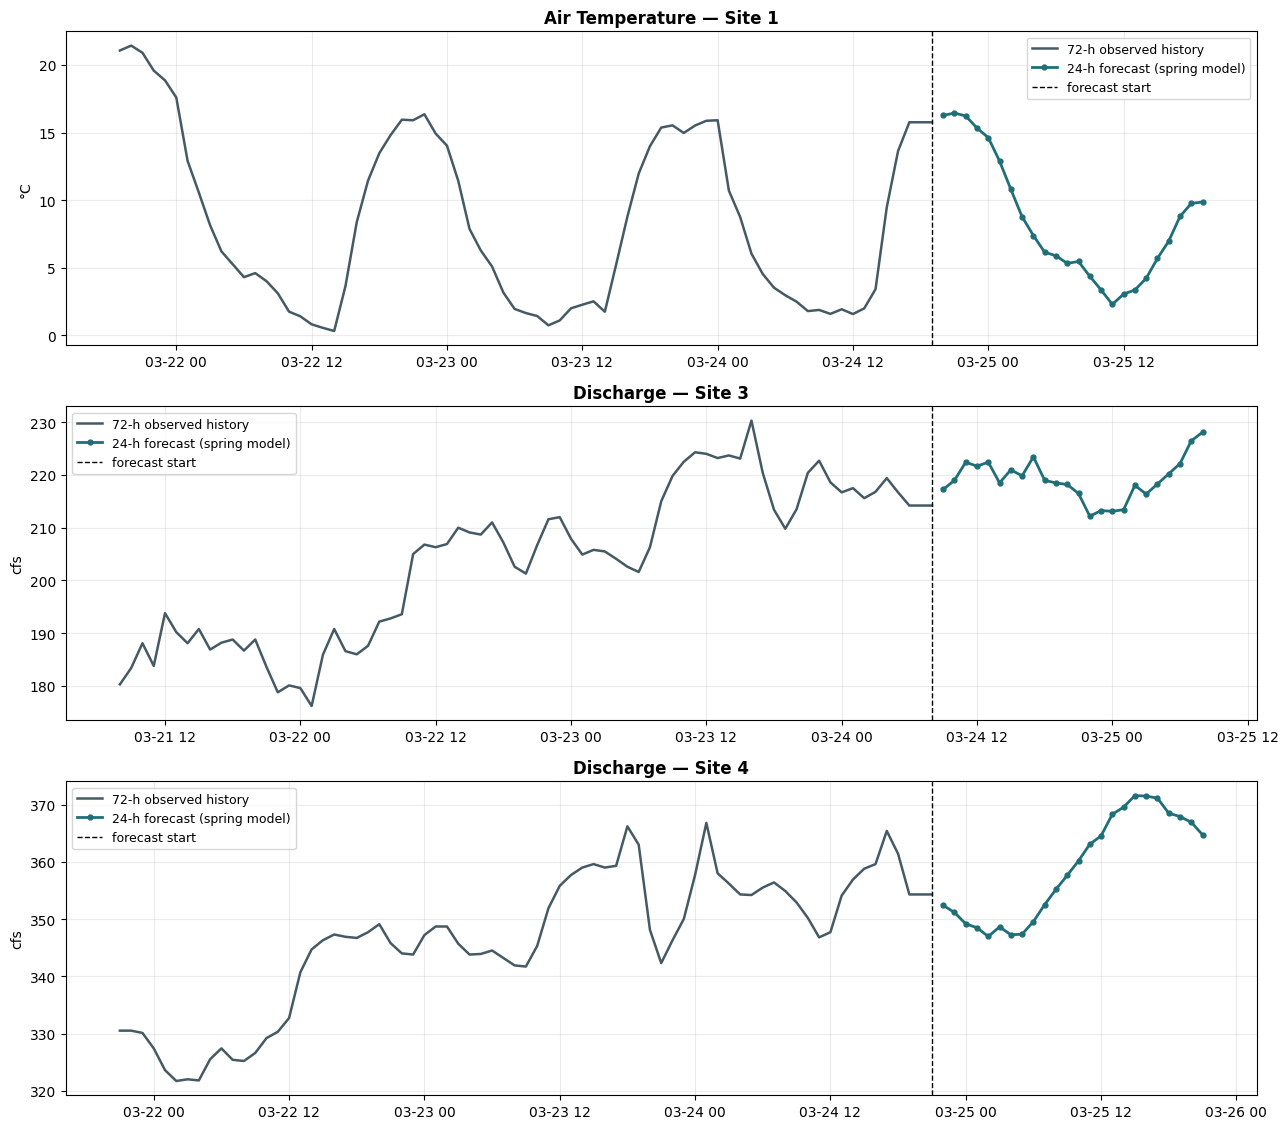

In [6]:
if pred_df.empty:
    print("No predictions to plot.")
else:
    pred_df["history_end_time"] = pd.to_datetime(pred_df["history_end_time"])
    pred_df["target_timestamp"] = pd.to_datetime(pred_df["target_timestamp"])

    unit_map = {"air_temperature": "°C", "discharge": "cfs"}
    groups   = list(pred_df.groupby(["target_variable", "site_id"], sort=True))

    fig, axes = plt.subplots(len(groups), 1, figsize=(13, 3.8 * len(groups)), sharex=False)
    if len(groups) == 1:
        axes = [axes]

    for ax, ((target_variable, site_id), grp) in zip(axes, groups):
        config        = inference.TARGET_CONFIGS[target_variable]
        history_end   = grp["history_end_time"].iloc[0].to_pydatetime()
        history_start = history_end - timedelta(hours=72)

        history = inference.build_hourly_series(
            conn,
            site_id=int(site_id),
            variable_code=config.variable_code,
            start_time=history_start,
            end_time=history_end,
            allow_negative=config.allow_negative,
            fill_mode="interpolate",
        )

        grp_sorted = grp.sort_values("horizon")
        unit       = unit_map.get(target_variable, "")
        season     = grp_sorted["season"].iloc[0]

        ax.plot(history["datetime"], history["value"],
                color="#455a64", linewidth=1.8, label="72-h observed history")
        ax.plot(grp_sorted["target_timestamp"], grp_sorted["prediction"],
                color="#1f6f78", marker="o", markersize=3.5, linewidth=2,
                label=f"24-h forecast ({season} model)")
        ax.axvline(history_end, color="black", linestyle="--", linewidth=1, label="forecast start")
        ax.set_title(f"{target_variable.replace('_', ' ').title()} — Site {int(site_id)}",
                     fontsize=12, fontweight="bold")
        ax.set_ylabel(unit)
        ax.legend(loc="best", fontsize=9)
        ax.grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()

## 6. Clean up — delete test rows and their predictions

In [7]:
ids_to_clean = list(globals().get("inserted_ids", []))

if not ids_to_clean:
    print("Nothing to clean up.")
else:
    with conn.cursor() as cur:
        cur.execute("DELETE FROM model_predictions WHERE source_datastream_id = ANY(%s)", (ids_to_clean,))
        p = cur.rowcount
        cur.execute("DELETE FROM datastream WHERE datastream_id = ANY(%s)", (ids_to_clean,))
        d = cur.rowcount
    conn.commit()
    print(f"Deleted {p} prediction rows and {d} datastream rows: {ids_to_clean}")

conn.close()
print("Connection closed.")

Deleted 72 prediction rows and 3 datastream rows: [4067886, 4067887, 4067888]
Connection closed.
